In [ ]:
# Importe librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carge los datos
df = pd.read_csv("Sales Data.csv")

In [ ]:
# Visualece las primeras 5 filas para confirmar que se cargó correctamente
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [ ]:
# Procedi a traducir las columnas
df.rename(columns={
    'Unnamed: 0': 'Indice',
    'Order ID': 'ID de Pedido',
    'Product': 'Producto',
    'Quantity Ordered': 'Cantidad de Productos',
    'Price Each': 'Precio Unitario',
    'Order Date': 'Fecha del Pedido',
    'Purchase Address': 'Dirección de Compra',
    'Month': 'Mes',
    'Sales': 'Total Ventas',
    'City': 'Ciudad',
    'Hour': 'Hora'
}, inplace=True)

In [ ]:
# Nombres de las Columnas
print(df.columns)

Index(['Indice', 'ID de Pedido', 'Producto', 'Cantidad de Productos',
       'Precio Unitario', 'Fecha del Pedido', 'Dirección de Compra', 'Mes',
       'Total Ventas', 'Ciudad', 'Hora'],
      dtype='object')


In [ ]:
# Descripción de las columnas
df.describe()

,Indice,ID de Pedido,Cantidad de Productos,Precio Unitario,Mes,Total Ventas,Hora
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [ ]:
# Revise cuántos valores faltan en cada columna
print(df.isnull().sum())


Indice                   0
ID de Pedido             0
Producto                 0
Cantidad de Productos    0
Precio Unitario          0
Fecha del Pedido         0
Dirección de Compra      0
Mes                      0
Total Ventas             0
Ciudad                   0
Hora                     0
dtype: int64


In [ ]:
# Inspeccione la estructura y los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Indice                 185950 non-null  int64  
 1   ID de Pedido           185950 non-null  int64  
 2   Producto               185950 non-null  object 
 3   Cantidad de Productos  185950 non-null  int64  
 4   Precio Unitario        185950 non-null  float64
 5   Fecha del Pedido       185950 non-null  object 
 6   Dirección de Compra    185950 non-null  object 
 7   Mes                    185950 non-null  int64  
 8   Total Ventas           185950 non-null  float64
 9   Ciudad                 185950 non-null  object 
 10  Hora                   185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


In [ ]:
# Converti la columna "Fecha del Pedido" a formato de fecha, para poder manipular y análizar
df['Fecha del Pedido'] = pd.to_datetime(df['Fecha del Pedido'], errors='coerce')
df['Mes'] = df['Fecha del Pedido'].dt.month
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Indice                 185950 non-null  int64         
 1   ID de Pedido           185950 non-null  int64         
 2   Producto               185950 non-null  object        
 3   Cantidad de Productos  185950 non-null  int64         
 4   Precio Unitario        185950 non-null  float64       
 5   Fecha del Pedido       185950 non-null  datetime64[ns]
 6   Dirección de Compra    185950 non-null  object        
 7   Mes                    185950 non-null  int32         
 8   Total Ventas           185950 non-null  float64       
 9   Ciudad                 185950 non-null  object        
 10  Hora                   185950 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(4), object(3)
memory usage: 14.9+ MB


In [ ]:
# Inspeccione la estructura y los datos por segunda vez
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Indice                 185950 non-null  int64  
 1   ID de Pedido           185950 non-null  int64  
 2   Producto               185950 non-null  object 
 3   Cantidad de Productos  185950 non-null  int64  
 4   Precio Unitario        185950 non-null  float64
 5   Fecha del Pedido       185950 non-null  object 
 6   Dirección de Compra    185950 non-null  object 
 7   Mes                    185950 non-null  int64  
 8   Total Ventas           185950 non-null  float64
 9   Ciudad                 185950 non-null  object 
 10  Hora                   185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


In [ ]:
df.shape # Ver las filas y columnas

(185950, 11)

In [ ]:
# Redondee los valores de la columna
df["Total Ventas"] = df["Total Ventas"].round(2)

In [ ]:
# visualece los datos duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Visualice los datos nulos
df.isna().sum()

,0
Indice,0
ID de Pedido,0
Producto,0
Cantidad de Productos,0
Precio Unitario,0
Fecha del Pedido,0
Dirección de Compra,0
Mes,0
Total Ventas,0
Ciudad,0


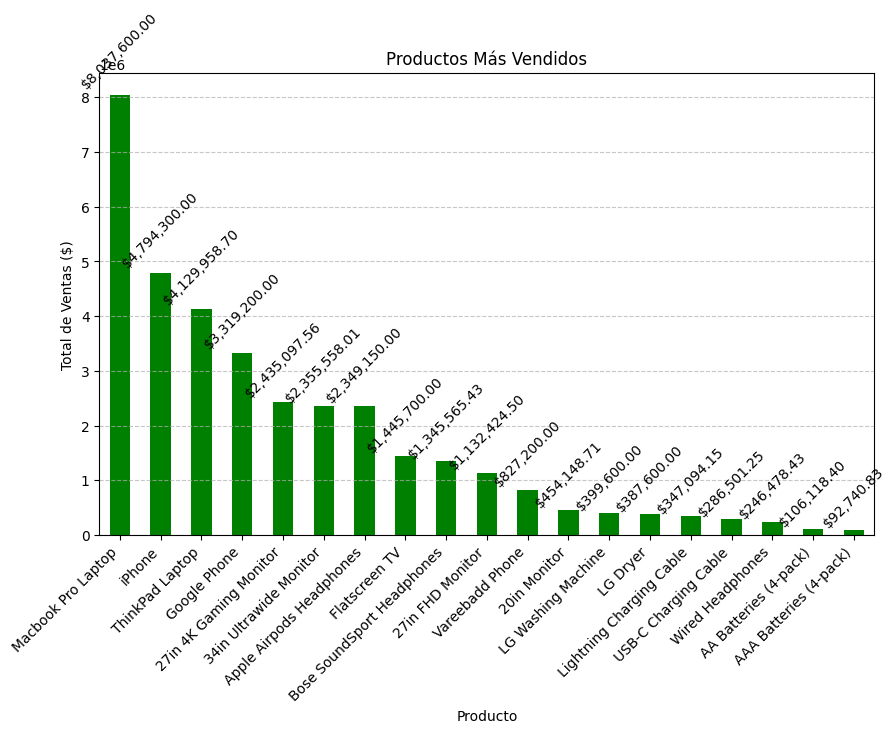

In [ ]:
import matplotlib.pyplot as plt

# Agrupe ventas por producto
ventas_por_producto = df.groupby('Producto')['Total Ventas'].sum().sort_values(ascending=False)

# Cree el gráfico de barras
plt.figure(figsize=(10, 6))
ax = ventas_por_producto.plot(kind='bar', color='green')

# Personalice el gráfico
plt.title('Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Total de Ventas ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Visualice valores en cada barra
for i, valor in enumerate(ventas_por_producto):
    ax.text(i, valor + (valor * 0.01), f'${valor:,.2f}', ha='center', va='bottom', fontsize=10, rotation=45)

# Visualice el gráfico
plt.show()


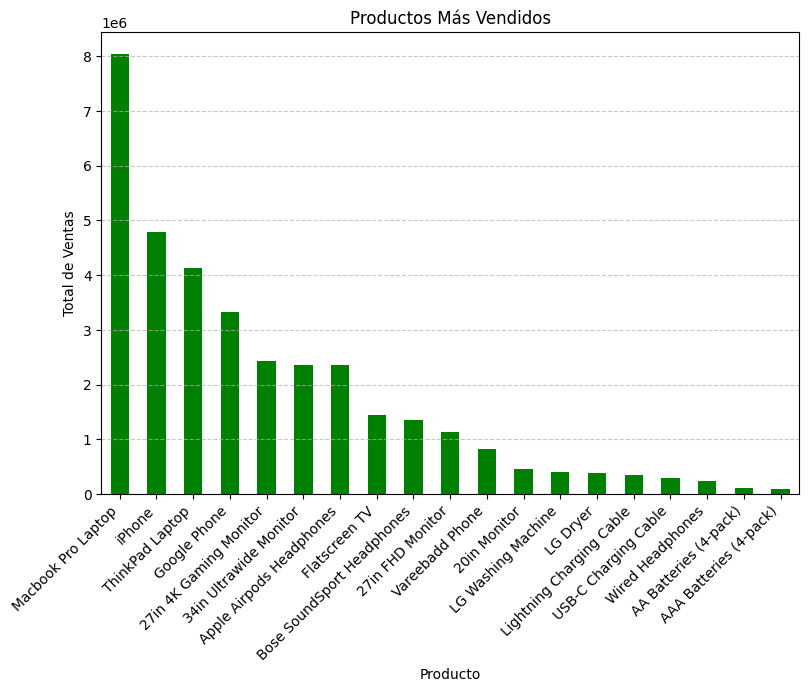

In [ ]:
import matplotlib.pyplot as plt

# Agrupe ventas por producto
ventas_por_producto = df.groupby('Producto')['Total Ventas'].sum().sort_values(ascending=False)

# Cree el gráfico de barras
plt.figure(figsize=(9,6))
ventas_por_producto.plot(kind='bar', color='green')

# Personalice el gráfico
plt.title('Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Total de Ventas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Visualice el gráfico
plt.show()


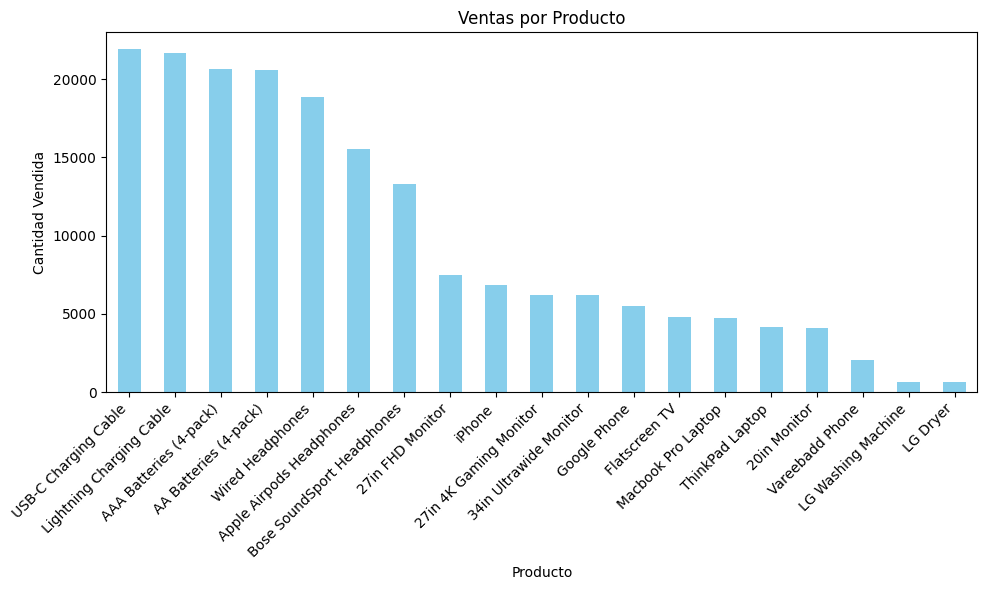

In [ ]:
# Producto más vendido
producto_mas_vendido = df["Producto"].value_counts().idxmax()
cantidad_producto_mas_vendido = df["Producto"].value_counts().max()

# Cree gráfico de barras para visualizar la distribución de ventas por producto
producto_ventas = df["Producto"].value_counts()

# Cree la gráfica
plt.figure(figsize=(10, 6))
producto_ventas.plot(kind='bar', color='skyblue')
plt.title('Ventas por Producto')
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Visualice el gráfico.
plt.show()


In [ ]:
# Calcule el total de ventas por producto
ventas_por_producto = df.groupby('Producto')['Total Ventas'].sum()

# Agrege la nueva columna al DataFrame original
df['Total Ventas Producto'] = df['Producto'].map(ventas_por_producto)

# Visualice las primeras filas para verificar
df.head()


,Indice,ID de Pedido,Producto,Cantidad de Productos,Precio Unitario,Fecha del Pedido,Dirección de Compra,Mes,Total Ventas,Ciudad,Hora,Total Ventas Producto
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0,8037600.00
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7,399600.00
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18,286501.25
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,1132424.50
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,286501.25


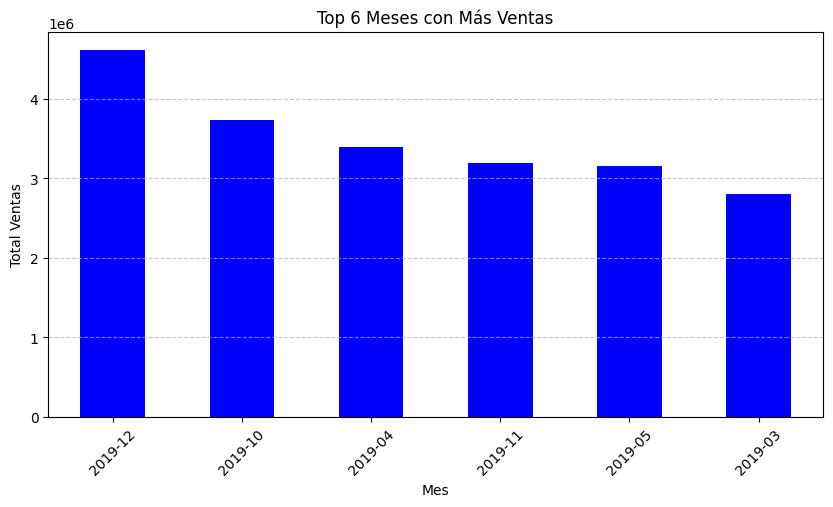

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Verifique si 'Fecha del Pedido' y 'Total Ventas' existen
if 'Fecha del Pedido' in df.columns and 'Total Ventas' in df.columns:
    # Extraje el mes y agrupe por mes
    df['Mes'] = df['Fecha del Pedido'].dt.to_period('M')  # Convierte a formato Año-Mes
    ventas_por_mes = df.groupby('Mes')['Total Ventas'].sum().sort_values(ascending=False)  # Ordene de mayor a menor

    # 📊 Grafique los 6 meses con más ventas
    plt.figure(figsize=(10, 5))
    ventas_por_mes.head(6).plot(kind='bar', color='b')
    plt.xlabel("Mes")
    plt.ylabel("Total Ventas")
    plt.title("Top 6 Meses con Más Ventas")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print()



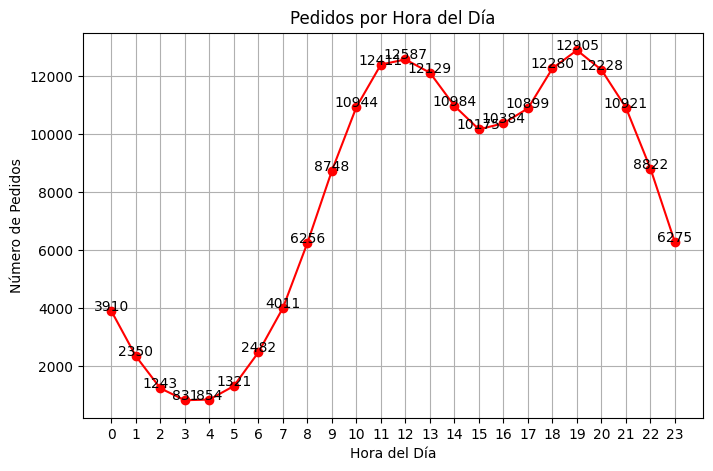

In [ ]:
# Agrupe por hora
compras_por_hora = df.groupby('Hora')['ID de Pedido'].count()

plt.figure(figsize=(8, 5))
plt.plot(compras_por_hora.index, compras_por_hora.values, marker='o', linestyle='-', color='red')

# Agrege etiquetas de valores en cada punto
for i, v in zip(compras_por_hora.index, compras_por_hora.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10, color='black')

plt.xlabel("Hora del Día")
plt.ylabel("Número de Pedidos")
plt.title("Pedidos por Hora del Día")
plt.xticks(range(0, 24))  # Mostre todas las horas
plt.grid(True)
plt.show()


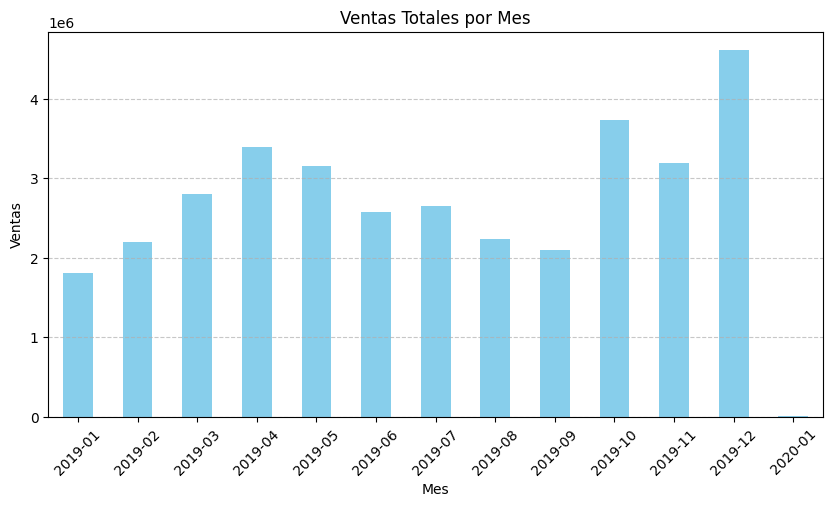

In [ ]:
# Agrupe datos por mes y calcular las ventas totales
ventas_por_mes = df.groupby('Mes')['Total Ventas'].sum()

# Cree el gráfico
plt.figure(figsize=(10, 5))
ventas_por_mes.plot(kind='bar', color='skyblue')

# Personalice el gráfico
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Visualice el gráfico
plt.show()


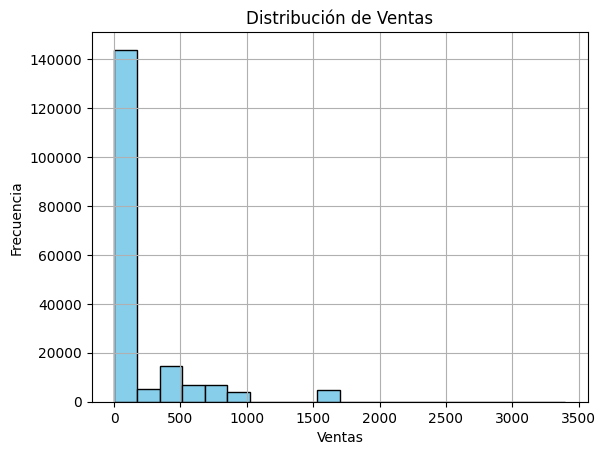

Total de Productos Vendidos: 209079


In [ ]:
# Total de productos vendidos
total_productos = df["Cantidad de Productos"].sum()
# 1. Histograma de ventas
df["Total Ventas"].hist(bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ventas")
plt.show()
print(f"Total de Productos Vendidos: {total_productos}")

In [ ]:
import pandas as pd

# Verifique las columnas
print("Columnas del DataFrame:", df.columns)

# Verifique si hay valores nulos en "Cantidad de Productos"
print("Valores nulos en 'Cantidad de Productos':", df["Cantidad de Productos"].isnull().sum())

# Converti la columna a numérica para evitar errores
df["Cantidad de Productos"] = pd.to_numeric(df["Cantidad de Productos"], errors="coerce")

# Elimine valores nulos si los hay
df.dropna(subset=["Cantidad de Productos"], inplace=True)

# Calcule el total de productos vendidos
total_productos = df["Cantidad de Productos"].sum()

# Mostre una muestra aleatoria para verificar valores
print(df.sample(10)[["Cantidad de Productos"]])

# Imprimi el resultado final
print(f"Total de Productos Vendidos: {total_productos}")


Columnas del DataFrame: Index(['Indice', 'ID de Pedido', 'Producto', 'Cantidad de Productos',
       'Precio Unitario', 'Fecha del Pedido', 'Dirección de Compra', 'Mes',
       'Total Ventas', 'Ciudad', 'Hora', 'Total Ventas Producto'],
      dtype='object')
Valores nulos en 'Cantidad de Productos': 0
        Cantidad de Productos
35743                       1
2616                        1
64301                       1
47280                       1
152061                      1
112198                      1
59868                       1
180002                      1
149734                      1
77909                       2
Total de Productos Vendidos: 209079


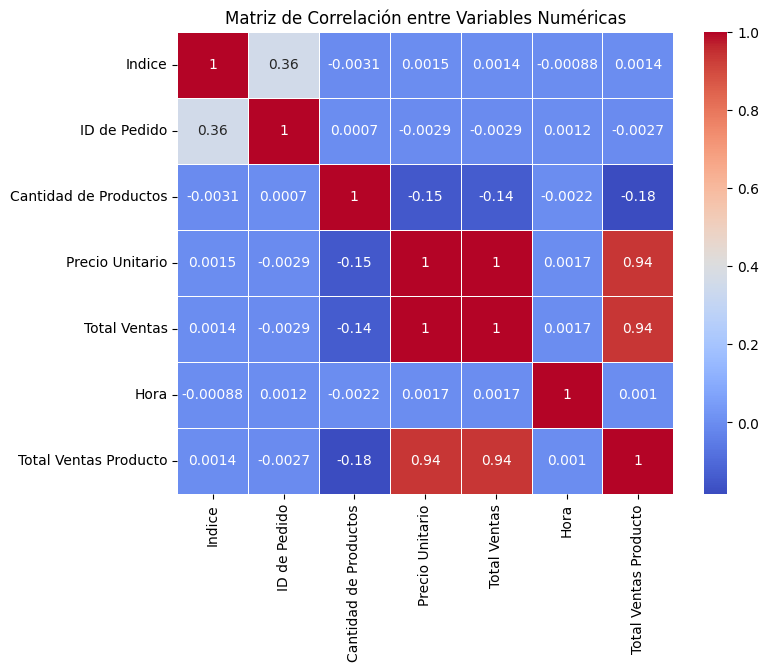

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccione solo columnas numéricas
df_numerico = df.select_dtypes(include=['number'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', linewidths=0.5)

# Título del gráfico
plt.title("Matriz de Correlación entre Variables Numéricas")

plt.show()
# 🔴 Cercano a 1 → Correlación positiva fuerte (cuando una variable sube, la otra también).
# 🔵 Cercano a 1 → Correlación negativa fuerte (cuando una variable sube, la otra baja).
# ⚪ Cercano a 0 → No hay relación entre las variables.

<ipython-input-124-37bb03f59087>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ciudad', order=df['Ciudad'].value_counts().index, palette="coolwarm")


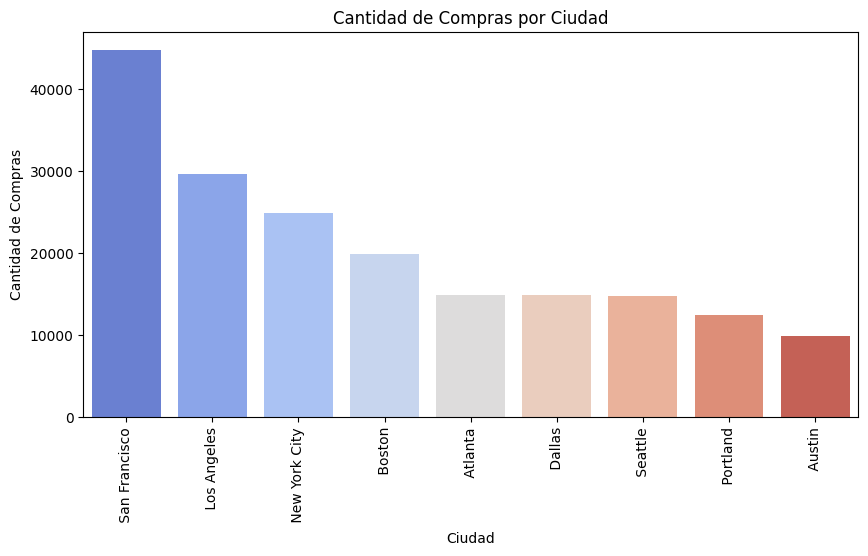

In [ ]:
# Cantidad de Compras por Ciudad
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Ciudad', order=df['Ciudad'].value_counts().index, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de Compras")
plt.title("Cantidad de Compras por Ciudad")
plt.show()


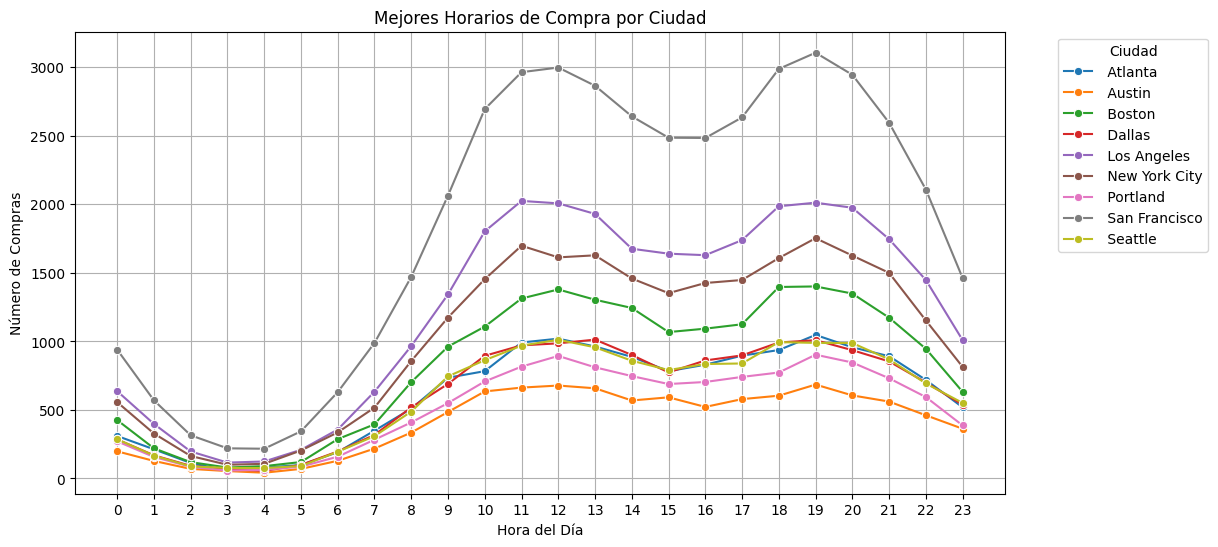

In [ ]:
# Compras por ciudad y por hora
compras_ciudad_hora = df.groupby(['Ciudad', 'Hora'])['ID de Pedido'].count().reset_index()

# Cree gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(data=compras_ciudad_hora, x='Hora', y='ID de Pedido', hue='Ciudad', marker="o")

plt.xlabel("Hora del Día")
plt.ylabel("Número de Compras")
plt.title("Mejores Horarios de Compra por Ciudad")
plt.xticks(range(0, 24))  # Mostre todas las horas
plt.legend(title="Ciudad", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



In [ ]:
# Descarge el archivo
df.to_csv('Sales_Data_Nuevo.csv', index=False)
from google.colab import files
files.download('Sales_Data_Nuevo.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>